In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sys
import os
import numpy as np
import joblib
from collections import Counter
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Add src folder to path for module importing
sys.path.append(os.path.abspath('../'))
from src.preprocess import run_full_preprocessing

# Load dataset
file_path = '../data/shopee_phone_case_dataset.csv'
df_raw = pd.read_csv(file_path, sep=';', encoding='cp1252')
print(f"Data Loaded Successfully! Initial row count: {len(df_raw)}")

Data Loaded Successfully! Initial row count: 1000


In [8]:
# Remove duplicate records
duplicate_count = df_raw.duplicated().sum()
df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed: {duplicate_count}")

# Execute main preprocessing pipeline
df = run_full_preprocessing(df)

# Impute missing values for numerical columns using median
numerical_cols = ['current_price_clean', 'original_price_clean', 'units_sold_clean', 'rating_score_clean', 'rating_count_clean']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

print("Data Cleaning & Preprocessing Task Completed!")

Duplicates removed: 0
Data Cleaning & Preprocessing Task Completed!


Median Units Sold: 1000.0


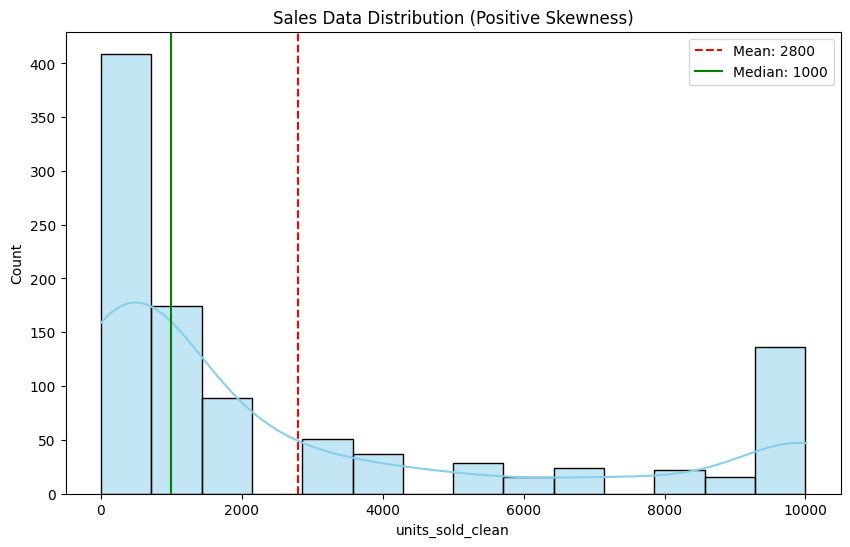

Target labeling completed with threshold: 1000


In [9]:
# Calculate median sales for thresholding
median_sold = df['units_sold_clean'].median()
print(f"Median Units Sold: {median_sold}")

# Visualize sales distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['units_sold_clean'], kde=True, color='skyblue')
plt.axvline(df['units_sold_clean'].mean(), color='red', linestyle='--', label=f'Mean: {df["units_sold_clean"].mean():.0f}')
plt.axvline(median_sold, color='green', linestyle='-', label=f'Median: {median_sold:.0f}')
plt.title('Sales Data Distribution (Positive Skewness)')
plt.legend()
plt.show()

# Define target variable based on successful sales threshold (1000 units)
threshold = 1000
df['target'] = df['units_sold_clean'].apply(lambda x: 1 if x >= threshold else 0)
print(f"Target labeling completed with threshold: {threshold}")

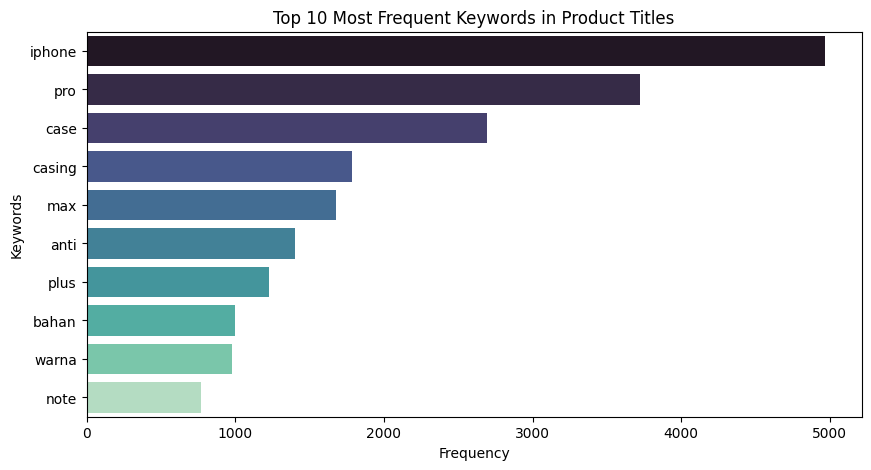

In [10]:
# Analyze Top 10 most frequent keywords in titles
all_final_tokens = [token for sublist in df['text_final'].str.split() for token in sublist]
top_10_words = Counter(all_final_tokens).most_common(10)
words, counts = zip(*top_10_words)

plt.figure(figsize=(10, 5))
# Using 'mako' palette and assigning x to hue for better visualization
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='mako', legend=False)

plt.title('Top 10 Most Frequent Keywords in Product Titles')
plt.xlabel('Frequency')
plt.ylabel('Keywords')
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_3844\2514164882.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='rep_score', data=df, palette='viridis')


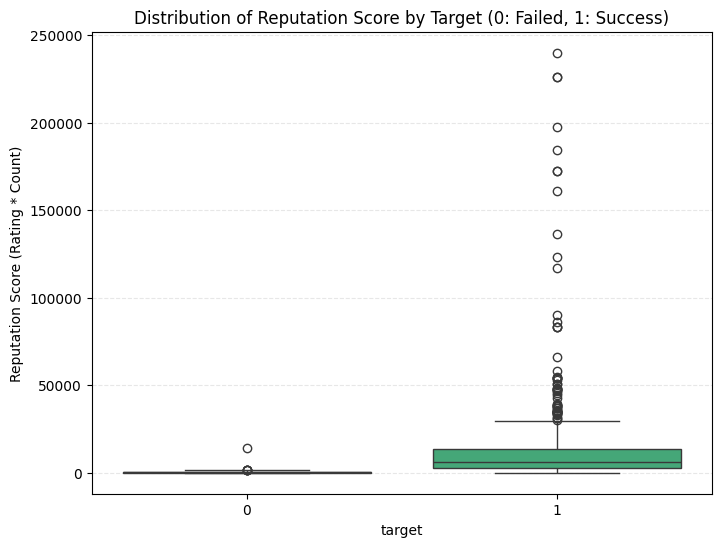

In [11]:
# Visualize Reputation Score distribution across target classes
plt.figure(figsize=(8, 6))
sns.boxplot(x='target', y='rep_score', data=df, palette='viridis')
plt.title('Distribution of Reputation Score by Target (0: Failed, 1: Success)')
plt.ylabel('Reputation Score (Rating * Count)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_3844\352570252.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gradient_Boosting', y='Feature', data=top_10_gb_txt, ax=ax_gb_txt, palette='rocket')
C:\Users\ACER\AppData\Local\Temp\ipykernel_3844\352570252.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Random_Forest', y='Feature', data=top_10_rf_txt, ax=ax_rf_txt, palette='cubehelix')


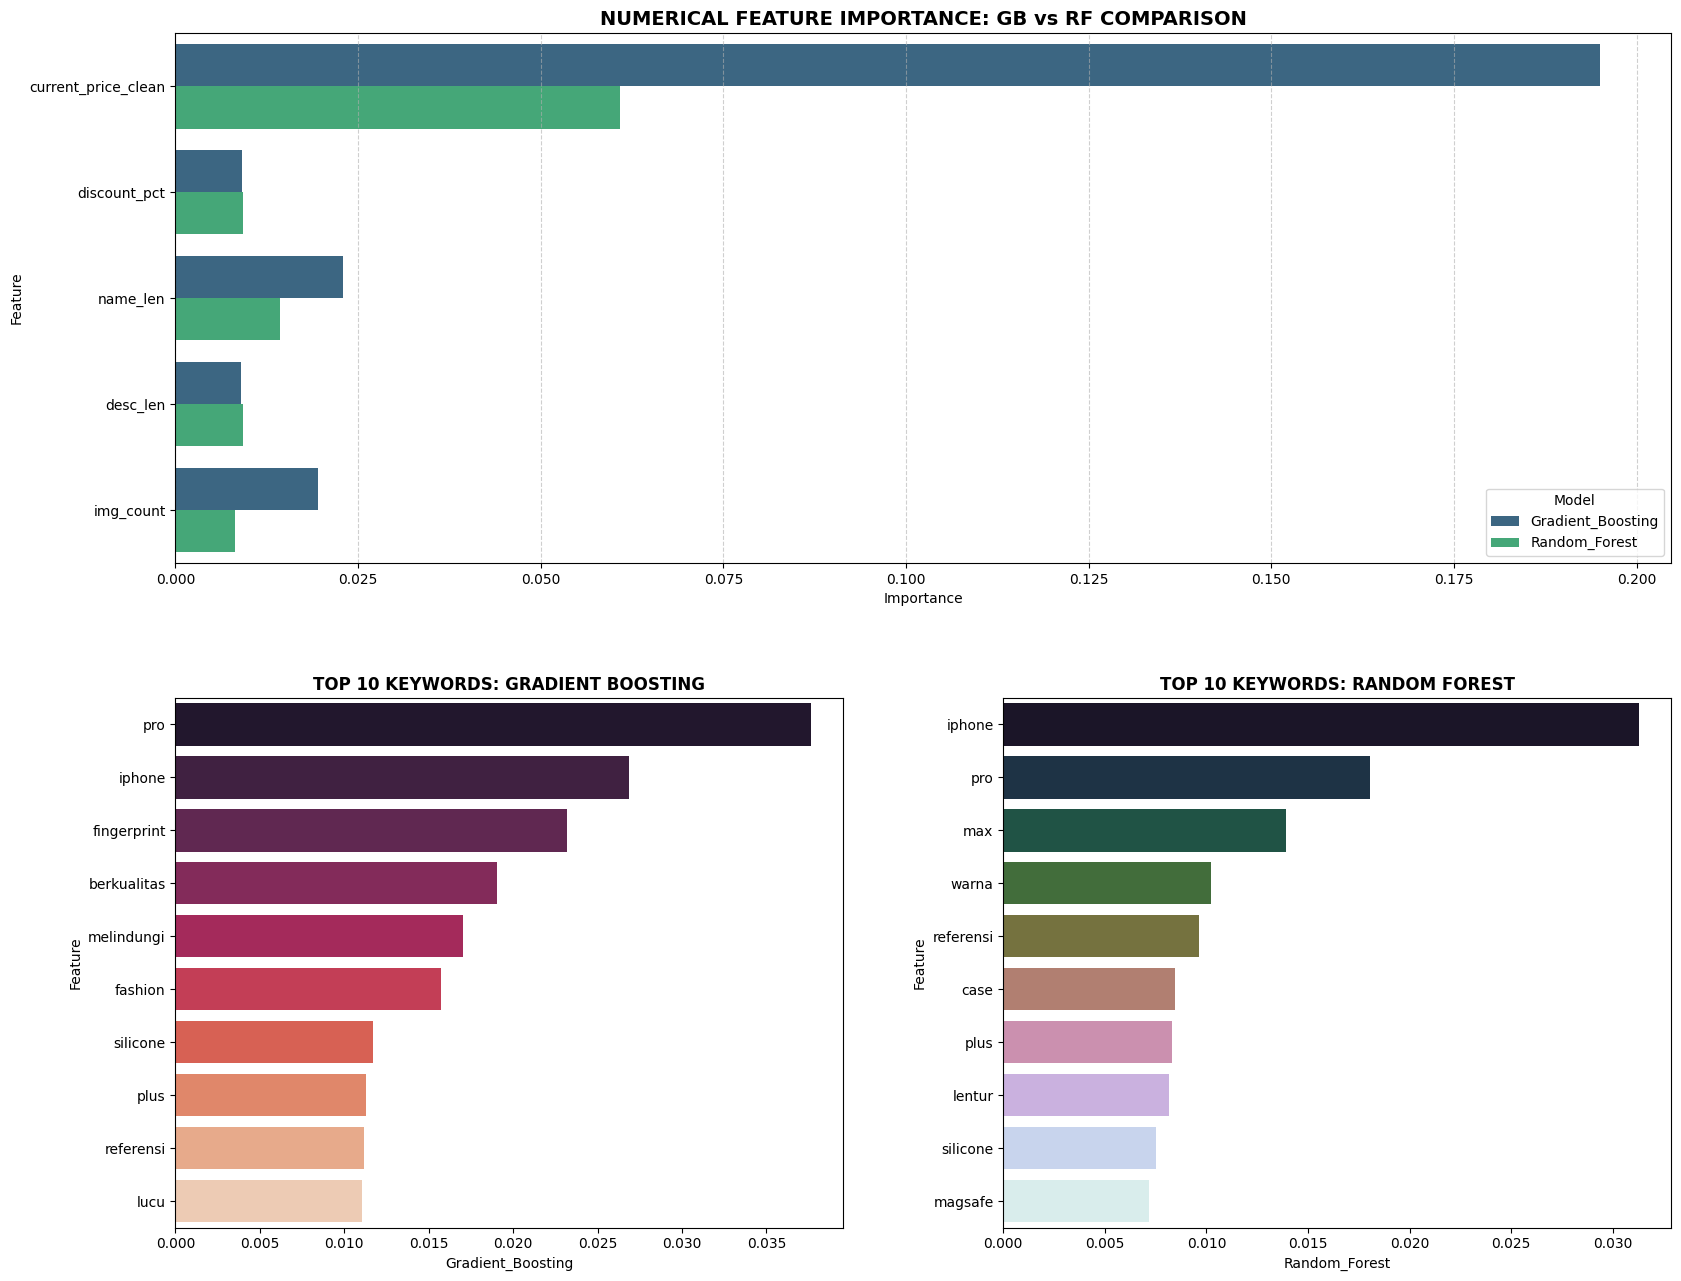

--- CLASSIFICATION REPORT: GRADIENT BOOSTING ---
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       458
           1       0.95      0.97      0.96       542

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000


--- CLASSIFICATION REPORT: RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       458
           1       0.93      0.97      0.95       542

    accuracy                           0.94      1000
   macro avg       0.95      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



In [12]:
# 1. Load trained models and vectorizer
model_gb = joblib.load('../models/shopee_model_gb.pkl')
model_rf = joblib.load('../models/shopee_model_rf.pkl')
tfidf_vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')

# 2. Prepare feature names
numerical_features = ['current_price_clean', 'discount_pct', 'name_len', 'desc_len', 'img_count']
text_features = list(tfidf_vectorizer.get_feature_names_out())
all_feature_names = numerical_features + text_features

# 3. Create Feature Importance DataFrame
df_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Gradient_Boosting': model_gb.feature_importances_,
    'Random_Forest': model_rf.feature_importances_
})

# 4. Setup visualization grid (1 row for Numerical, 1 row for Textual)
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2)

# --- TOP ROW: Grouped Numerical Importance (Comparison) ---
ax_num = fig.add_subplot(gs[0, :])
df_num_only = df_importance[df_importance['Feature'].isin(numerical_features)]
df_num_melted = df_num_only.melt(id_vars='Feature', var_name='Model', value_name='Importance')

sns.barplot(x='Importance', y='Feature', hue='Model', data=df_num_melted, ax=ax_num, palette='viridis')
ax_num.set_title('NUMERICAL FEATURE IMPORTANCE: GB vs RF COMPARISON', fontsize=14, fontweight='bold')
ax_num.grid(axis='x', linestyle='--', alpha=0.6)

# --- BOTTOM ROW: Top 10 Keywords for each model ---
df_txt_only = df_importance[~df_importance['Feature'].isin(numerical_features)]

# Plot GB Top Keywords
ax_gb_txt = fig.add_subplot(gs[1, 0])
top_10_gb_txt = df_txt_only.sort_values(by='Gradient_Boosting', ascending=False).head(10)
sns.barplot(x='Gradient_Boosting', y='Feature', data=top_10_gb_txt, ax=ax_gb_txt, palette='rocket')
ax_gb_txt.set_title('TOP 10 KEYWORDS: GRADIENT BOOSTING', fontsize=12, fontweight='bold')

# Plot RF Top Keywords
ax_rf_txt = fig.add_subplot(gs[1, 1])
top_10_rf_txt = df_txt_only.sort_values(by='Random_Forest', ascending=False).head(10)
sns.barplot(x='Random_Forest', y='Feature', data=top_10_rf_txt, ax=ax_rf_txt, palette='cubehelix')
ax_rf_txt.set_title('TOP 10 KEYWORDS: RANDOM FOREST', fontsize=12, fontweight='bold')

plt.tight_layout(pad=5.0)
plt.show()

# 5. Print Performance Reports
num_features_vals = df[numerical_features].values
text_features_vals = tfidf_vectorizer.transform(df['text_final']).toarray()
X_total = np.hstack((num_features_vals, text_features_vals))
y_true = df['target']

print("--- CLASSIFICATION REPORT: GRADIENT BOOSTING ---")
print(classification_report(y_true, model_gb.predict(X_total)))
print("\n--- CLASSIFICATION REPORT: RANDOM FOREST ---")
print(classification_report(y_true, model_rf.predict(X_total)))